# Assignment 1 — Uncertainty and Sentiment Analysis of Quarterly and Annual Financial Reports

**FRE-GY 7871 A · NLP and the Investment Process**

Two measures — Loughran–McDonald Fin-Neg (sentiment) and Fin-Unc (uncertainty) — scored on every
10-K and 10-Q filed 2021–2025 by the SEC filers held in the six ARK ETFs. Each measure is computed
two ways: as a share of total words, and with the tf.idf weighting of equation (1) in
Loughran & McDonald (2011).

The notebook runs in the order of the report: build the sample, score it, then Tables 1–6 and
Figure 1. The data pipeline (`scripts/00`–`03`) must have been run first.

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT))

from src.config import INTERIM_DIR, OUTPUT_DIR, PRICE_DIR, UNIVERSE_DIR
from src.lexicons import load_all
from src import tone, events, regress, exhibits

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

COUNTS_PATH = INTERIM_DIR / "counts.csv.gz"
print("root:", ROOT)

root: /Users/yuri/Desktop/Financial Engineering/Year 2/NLP/HW 1 - Repo


## 1. Load

`filings_meta.csv` is one row per filing, written by `scripts/02`. `acceptance_datetime` is the
column that makes the point-in-time work: it is the moment EDGAR actually received the document,
in UTC.

In [2]:
meta = pd.read_csv(INTERIM_DIR / "filings_meta.csv", dtype={"cik": str},
                   parse_dates=["filing_date", "report_date"])
print(f"{len(meta)} filings, {meta['cik'].nunique()} unique CIKs, {meta['ticker'].nunique()} tickers")
display(meta.groupby("form")["n_words"].describe()[["count", "mean", "50%", "min", "max"]])

prices = pd.read_csv(PRICE_DIR / "prices.csv", index_col=0, parse_dates=True)
volume = pd.read_csv(PRICE_DIR / "volume.csv", index_col=0, parse_dates=True)
shares = pd.read_csv(PRICE_DIR / "shares.csv", dtype={"cik": str})
print(f"prices {prices.shape}  volume {volume.shape}  share facts {len(shares)}")

1702 filings, 92 unique CIKs, 93 tickers


,count,mean,50%,min,max
form,,,,,
10-K,416.0000,"50,999.9880","49,081.5000","17,774.0000","118,811.0000"
10-Q,"1,286.0000","21,483.9082","13,087.0000","3,388.0000","78,194.0000"


prices (1400, 96)  volume (1400, 96)  share facts 3542


## 2. Word lists

Both lists come from the Loughran–McDonald Master Dictionary. The overlap between them is the
first thing to look at: it puts a floor under how independent the two measures can be.

In [3]:
word_lists = load_all()
neg, unc = word_lists["Negative"], word_lists["Uncertainty"]
vocab = neg | unc

overlap = neg & unc
print(f"Fin-Neg      {len(neg):5d} words")
print(f"Fin-Unc      {len(unc):5d} words")
print(f"overlap      {len(overlap):5d}  ({len(overlap)/len(unc):.1%} of Fin-Unc)")
print(f"union        {len(vocab):5d}")
print("\noverlapping words:", ", ".join(sorted(overlap)[:18]), "...")

Fin-Neg       2355 words
Fin-Unc        297 words
overlap         40  (13.5% of Fin-Unc)
union         2612

overlapping words: ANOMALIES, ANOMALOUS, ANOMALOUSLY, ANOMALY, CONFUSES, CONFUSING, CONFUSINGLY, CONFUSION, DESTABILIZING, DEVIATE, DEVIATED, DEVIATES, DEVIATING, DEVIATION, DEVIATIONS, DOUBT, DOUBTED, DOUBTFUL ...


## 3. Count matrix

One pass over the extracted text of every filing, keeping counts only for words on either list.
`n_words` and `n_distinct` (the inputs to the tf.idf normaliser `a_j`) are counted over *all*
tokens before that restriction, so the denominators stay right.

In [4]:
if COUNTS_PATH.exists():
    counts = pd.read_csv(COUNTS_PATH)
    print(f"loaded cached count matrix: {len(counts):,} rows")
else:
    counts = tone.build_counts(meta, vocab, ROOT)
    counts.to_csv(COUNTS_PATH, index=False)
    print(f"built count matrix: {len(counts):,} rows")

loaded cached count matrix: 387,904 rows


### The tf.idf self-check

Equation (1) with the README's three toy documents, run through the same functions that score the
real corpus. Expected: 0.8480, 0.2885, 0.5026. Natural logs — log base 10 gives 0.368 for d1.

In [5]:
display(tone.selfcheck().round(4))

,a_j,proportional,tfidf
accession,,,
d1,1.3333,0.7500,0.8480
d2,1.5000,0.3333,0.2885
d3,2.0000,0.7500,0.5026


## 4. Point-in-time: the day-0 rule

Day 0 is the first trading day on or after the later of the EDGAR filing date and the acceptance
date, where acceptance is pushed forward one day when it lands at or after 16:00 Eastern.
`acceptance_datetime` is UTC, so it is converted first.

In [6]:
cal = events.trading_calendar(prices)
print(f"trading calendar: {len(cal)} sessions, {cal[0].date()} to {cal[-1].date()}")

meta = events.assign_day0(meta, cal)
late, moved = meta["accepted_after_close"].sum(), meta["day0_moved"].sum()
print(f"accepted at or after 16:00 ET : {late:5d}  ({late/len(meta):.1%})")
print(f"day 0 moved vs the filing date: {moved:5d}  ({moved/len(meta):.1%})")

display(meta.loc[meta["day0_moved"], ["ticker", "form", "filing_date", "acceptance_et",
                                      "day0_naive", "day0"]].head(6))

trading calendar: 1400 sessions, 2020-09-01 to 2026-03-30


accepted at or after 16:00 ET :  1286  (75.6%)
day 0 moved vs the filing date:   951  (55.9%)


,ticker,form,filing_date,acceptance_et,day0_naive,day0
0,ABNB,10-K,2021-02-26,2021-02-26 16:19:13-05:00,2021-02-26,2021-03-01
1,ABNB,10-Q,2021-05-14,2021-05-14 17:18:14-04:00,2021-05-14,2021-05-17
2,ABNB,10-Q,2021-08-13,2021-08-13 16:05:47-04:00,2021-08-13,2021-08-16
3,ABNB,10-Q,2021-11-05,2021-11-05 16:32:10-04:00,2021-11-05,2021-11-08
4,ABNB,10-K,2022-02-25,2022-02-25 16:09:12-05:00,2022-02-25,2022-02-28
5,ABNB,10-Q,2022-05-09,2022-05-09 16:48:00-04:00,2022-05-09,2022-05-10


More filings are accepted after the close than are moved by the rule. The gap is filings whose
acceptance-plus-one lands on a weekend that the naive rule was already rolling past.

In [7]:
panel = events.build_event_panel(meta, prices, volume, cal)
panel = events.attach_shares(panel, shares)

matched = panel["shares_outstanding"].notna().mean()
print(f"share count matched on accession: {matched:.1%}")
print(f"filings with no share fact (left missing, not filled forward): "
      f"{panel['shares_outstanding'].isna().sum()}")
display(panel["shares_tag"].value_counts())

share count matched on accession: 96.3%
filings with no share fact (left missing, not filled forward): 63


shares_tag
dei:EntityCommonStockSharesOutstanding                     1089
us-gaap:WeightedAverageNumberOfDilutedSharesOutstanding     510
us-gaap:CommonStockSharesOutstanding                         36
us-gaap:WeightedAverageNumberOfSharesOutstandingBasic         4
Name: count, dtype: int64

## Table 1. Sample filters

The five filters in the brief's order, counting what each removes. Amendments never reach
`filings_meta.csv` — `src/edgar.py` excludes them at the query — so their count comes from a
separate query rather than being reported as a meaningless zero.

In [8]:
universe = pd.read_csv(UNIVERSE_DIR / "universe.csv", dtype={"cik": str})
filers = universe.query("status == 'domestic_filer'")
amd = events.count_amendments(filers, "2021-01-01", "2025-12-31")
n_amd = int(amd["n"].sum()) if len(amd) else 0
print(f"amendments filed in window: {n_amd}")

sample, table1 = events.apply_filters(panel, amendments_dropped=n_amd)
table1.to_csv(OUTPUT_DIR / "table1_waterfall.csv", index=False)
display(table1)
print(f"final sample: {len(sample)} filings, {sample['cik'].nunique()} firms, "
      f"{sample['form'].value_counts().to_dict()}")

amendments filed in window: 46


,filter,removed,remaining
0,"10-K and 10-Q filings, 2021-2025, 93 ARK filers",0,1702
1,"1a. Amendments (10-K/A, 10-Q/A), excluded at q...",46,1702
2,1b. Failed to parse (zero words),0,1702
3,"2. Below word floor (2,000 for 10-K, 1,000 for...",0,1702
4,3a. Dual-class listing (same filing under two ...,20,1682
5,3b. Multiple filings per company-quarter (earl...,14,1668
6,4a. No usable day 0,0,1668
7,4b. Price on day -1 below $3,103,1565
8,5. Fewer than 60 trading days of returns eithe...,23,1542


final sample: 1542 filings, 91 firms, {'10-Q': 1158, '10-K': 384}


Two filters do nothing, and that is worth stating rather than hiding: no filing failed to parse,
and none fell below the word floor — the shortest 10-K runs to 17,774 words and the shortest 10-Q
to 3,388, comfortably above the 2,000 / 1,000 thresholds. The floors are insurance against a
parser failure that did not happen.

The dual-class row is Alphabet: the ARK universe holds both GOOG and GOOGL, one CIK, one set of
filings, counted twice.

In [9]:
sample["quarter"] = pd.to_datetime(sample["filing_date"]).dt.to_period("Q")
qs = sorted(sample["quarter"].unique())
sample["t"] = sample["quarter"].map({q: i for i, q in enumerate(qs)})
sample["log_mktcap"] = np.log(sample["mktcap"])
sample["log_dvol"] = np.log(sample["dollar_volume"])
sample["log_words"] = np.log(sample["n_words"])
sample["is_10k"] = (sample["form"] == "10-K").astype(int)
print(f"{len(qs)} quarters: {qs[0]} to {qs[-1]}")

20 quarters: 2021Q1 to 2025Q4


## 5. Scoring

`N` and `df_i` are computed on the final filtered sample, and those same scores are used for every
exhibit and regression below. Scoring one corpus and regressing another would make the idf term
refer to a population the regressions never see.

In [10]:
scores = tone.score_corpus(counts, sample, word_lists)
sample = sample.merge(scores, on="accession", how="left")
MEAS = ["neg_prop", "unc_prop", "neg_tfidf", "unc_tfidf"]
display(sample[MEAS].describe().round(4))

,neg_prop,unc_prop,neg_tfidf,unc_tfidf
count,"1,542.0000","1,542.0000","1,542.0000","1,542.0000"
mean,0.0228,0.0200,99.0714,16.5233
std,0.0098,0.0060,80.7892,11.0963
min,0.0037,0.0063,2.1410,1.3407
25%,0.0134,0.0150,19.4879,7.2389
50%,0.0230,0.0200,96.1894,14.5969
75%,0.0319,0.0250,158.6476,23.5219
max,0.0538,0.0435,345.8852,64.1263


## Table 2. Summary statistics

In [11]:
t2 = exhibits.table2_summary(sample)
t2.to_csv(OUTPUT_DIR / "table2_summary.csv", index=False)
display(t2.round(4))

,form,measure,n,mean,sd,p10,median,p90
0,10-K,"Fin-Neg, proportional",384,0.0258,0.0054,0.0193,0.0258,0.0318
1,10-K,"Fin-Unc, proportional",384,0.0214,0.0036,0.0176,0.0215,0.0245
2,10-K,"Fin-Neg, tf.idf",384,168.7086,61.4641,96.6083,155.6389,260.5192
3,10-K,"Fin-Unc, tf.idf",384,27.8578,9.9408,16.7392,26.2323,42.3773
4,10-Q,"Fin-Neg, proportional",1158,0.0218,0.0107,0.0098,0.0178,0.0361
5,10-Q,"Fin-Unc, proportional",1158,0.0195,0.0066,0.0112,0.0178,0.0281
6,10-Q,"Fin-Neg, tf.idf",1158,75.9793,72.7969,9.5375,34.5278,186.5526
7,10-Q,"Fin-Unc, tf.idf",1158,12.7648,8.6316,3.6765,9.9298,24.9932
8,All,"Fin-Neg, proportional",1542,0.0228,0.0098,0.0105,0.0230,0.0353
9,All,"Fin-Unc, proportional",1542,0.0200,0.0060,0.0121,0.0200,0.0277


In [12]:
corr = exhibits.measure_correlations(sample)
corr.to_csv(OUTPUT_DIR / "table2b_correlations.csv", index=False)
display(corr.round(3))

,form,corr_proportional,corr_tfidf,corr_neg_prop_vs_tfidf,corr_unc_prop_vs_tfidf,n
0,10-K,0.8470,0.8560,0.5130,0.3710,384
1,10-Q,0.8820,0.9410,0.8840,0.7870,1158
2,All,0.8810,0.9330,0.7930,0.6320,1542


### Q2. Are sentiment and uncertainty measuring different things?

Largely not. Pooled, the two proportional measures correlate 0.88 and the two tf.idf measures 0.93.
Within form type the proportional correlation is 0.85 for 10-Ks and 0.88 for 10-Qs, so the pooled
figure is not just a 10-K/10-Q composition effect.

Three things drive it, and they are worth separating:

1. **Shared words.** 40 of the 297 Fin-Unc words are also on Fin-Neg — 13% of the uncertainty list.
2. **Shared length exposure.** Both measures rise with how much risk-factor prose a filing carries.
3. **Genuine co-movement.** Filings that discuss bad news also hedge.

The consequence for the rest of this report is stated plainly: Tables 5 and 6 are not two
independent tests. They use different dependent variables, which is what keeps them distinct, but
the right-hand-side variables are close to the same variable.

In [13]:
# A filing high on one measure and low on the other, to see what the residual variation looks like
z = sample.assign(zn=lambda d: (d.neg_prop - d.neg_prop.mean()) / d.neg_prop.std(),
                  zu=lambda d: (d.unc_prop - d.unc_prop.mean()) / d.unc_prop.std())
z["gap"] = z.zu - z.zn
cols = ["ticker", "form", "filing_date", "n_words", "neg_prop", "unc_prop", "gap"]
print("Most uncertainty relative to sentiment:")
display(z.nlargest(5, "gap")[cols].round(4))
print("Most sentiment relative to uncertainty:")
display(z.nsmallest(5, "gap")[cols].round(4))

Most uncertainty relative to sentiment:


,ticker,form,filing_date,n_words,neg_prop,unc_prop,gap
1090,GOOG,10-Q,2024-04-26,9779,0.0143,0.0262,1.9017
1094,GOOG,10-Q,2025-04-25,9051,0.0126,0.0243,1.7660
1095,GOOG,10-Q,2025-07-24,9597,0.0127,0.0240,1.6974
1096,GOOG,10-Q,2025-10-30,9808,0.0124,0.0232,1.6056
1078,GOOG,10-Q,2021-04-28,9285,0.0168,0.0258,1.5933


Most sentiment relative to uncertainty:


,ticker,form,filing_date,n_words,neg_prop,unc_prop,gap
1516,DKNG,10-Q,2024-11-08,14156,0.0504,0.0164,-3.4113
1515,DKNG,10-Q,2024-08-02,13877,0.0472,0.0173,-2.9303
1514,DKNG,10-Q,2024-05-03,12094,0.0485,0.0184,-2.8764
1510,DKNG,10-Q,2023-05-05,10834,0.0473,0.0185,-2.7424
1512,DKNG,10-Q,2023-11-03,12534,0.0458,0.0178,-2.7044


## Table 3. What the measures are made of

In [14]:
conc = exhibits.concentration(counts, word_lists, set(sample["accession"]))
conc.to_csv(OUTPUT_DIR / "table3b_concentration.csv", index=False)
display(conc.round(3))

t3 = exhibits.table3_top_words(counts, word_lists, set(sample["accession"]), top=30)
t3.to_csv(OUTPUT_DIR / "table3_top_words.csv", index=False)
for lst in t3["list"].unique():
    print(f"\n{lst} — 30 most frequent")
    display(t3[t3["list"] == lst].head(30).round(4).reset_index(drop=True))

,list,list_size,words_observed,top10_share,top30_share,top100_share
0,Fin-Neg,2355,1565,0.2740,0.4610,0.7100
1,Fin-Unc,297,243,0.7810,0.9240,0.9910



Fin-Neg — 30 most frequent


,list,rank,word,count,share_of_list,pct_of_filings
0,Fin-Neg,1,LOSS,58230,0.0477,1.0000
1,Fin-Neg,2,ADVERSELY,57139,0.0468,0.9332
2,Fin-Neg,3,ADVERSE,35361,0.0289,0.9150
3,Fin-Neg,4,CLAIMS,33073,0.0271,0.8340
4,Fin-Neg,5,HARM,26509,0.0217,0.6997
5,Fin-Neg,6,AGAINST,26090,0.0214,0.8677
6,Fin-Neg,7,UNABLE,26026,0.0213,0.7996
7,Fin-Neg,8,FAILURE,24775,0.0203,0.7750
8,Fin-Neg,9,LOSSES,24030,0.0197,0.9708
9,Fin-Neg,10,LITIGATION,23083,0.0189,0.9040



Fin-Unc — 30 most frequent


,list,rank,word,count,share_of_list,pct_of_filings
0,Fin-Unc,1,MAY,374819,0.3733,1.0000
1,Fin-Unc,2,COULD,207229,0.2064,1.0000
2,Fin-Unc,3,RISK,50741,0.0505,1.0000
3,Fin-Unc,4,RISKS,50099,0.0499,1.0000
4,Fin-Unc,5,BELIEVE,31454,0.0313,0.9929
5,Fin-Unc,6,APPROXIMATELY,18219,0.0181,0.9494
6,Fin-Unc,7,ASSUMPTIONS,13178,0.0131,0.9935
7,Fin-Unc,8,FLUCTUATIONS,13028,0.0130,0.8671
8,Fin-Unc,9,MIGHT,12478,0.0124,0.6822
9,Fin-Unc,10,UNCERTAINTIES,12383,0.0123,0.9903


### Q1. What is each measure actually made of?

**Fin-Unc is two words.** MAY is 37.3% of the entire uncertainty count and COULD another 20.6%.
The top ten words carry **78.1%** of the count, and the top thirty carry 92.4%. Only 243 of the
297 listed words appear at all.

That is decisive for how the measure should be read. MAY, COULD, RISK and RISKS each appear in
100% of filings, and APPROXIMATELY in 94.9%. These are not management hedging in the sense the
construct intends — they are the standing furniture of a risk-factor section that is largely
copied forward from the previous filing. What the proportional measure is really tracking is how
much of a filing is risk-factor boilerplate.

This is precisely the case for the tf.idf weighting: a word appearing in every filing gets
`ln(N/df) = ln(1) = 0` and drops out entirely. The two schemes are therefore measuring different
things, not the same thing more or less precisely.

**Fin-Neg is much better spread.** Its top ten carry 27.4% and 1,565 of 2,355 words appear. Its
leading terms — LOSS, ADVERSELY, ADVERSE, CLAIMS, HARM — are still heavily risk-factor
vocabulary, but no single word dominates the way MAY does.

## Figure 1 and Table 4. Trends, 2021–2025

Two composition problems have to be handled before anything is described. 10-Ks are longer and
heavier in risk language and they cluster in Q1, so a pooled quarterly mean carries an annual
sawtooth that is a calendar artefact. And firms differ enormously in baseline tone while filing in
different quarters. So: split by form type, and look within firm.

outputs/figure1.png


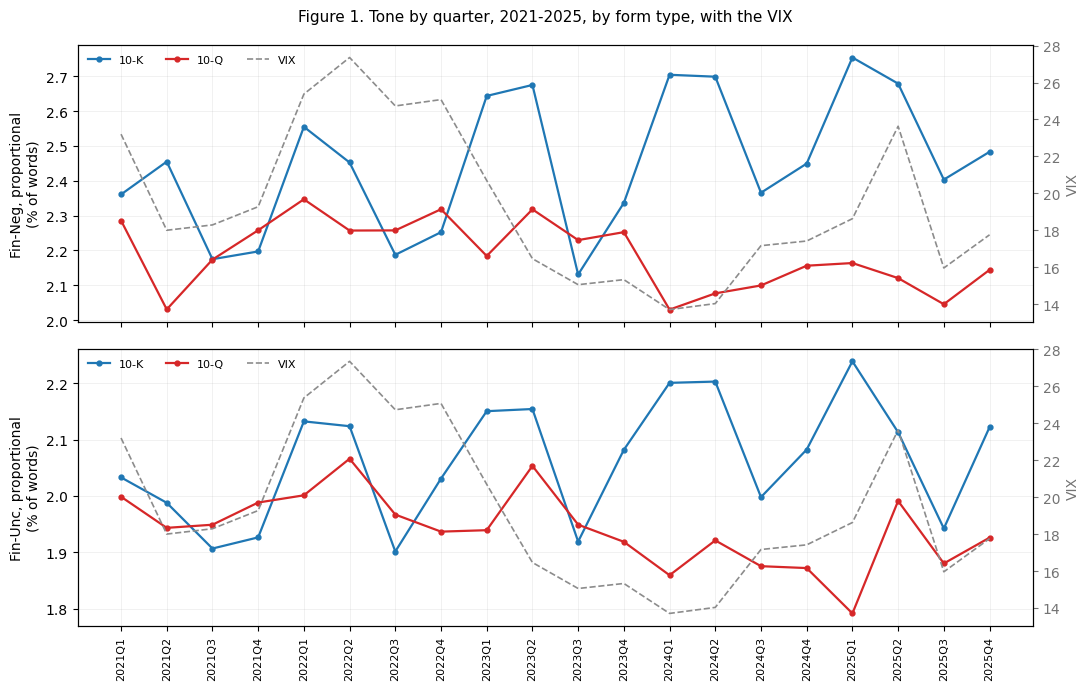

In [15]:
vix = prices["^VIX"].dropna()
qmeans = exhibits.figure1(sample, vix, OUTPUT_DIR / "figure1.png")
qmeans.to_csv(OUTPUT_DIR / "figure1_data.csv", index=False)
print("outputs/figure1.png")

In [16]:
rows = []
for m in MEAS:
    for form in ["10-K", "10-Q"]:
        sub = sample[sample["form"] == form]
        r = regress.aggregate_trend(sub.groupby("quarter")[m].mean())
        rows.append({**r, "measure": m, "sample": form, "test": "aggregate, Newey-West"})
    r = regress.within_firm_trend(sample, m)
    rows.append({**r, "measure": m, "sample": "pooled", "test": "within firm"})

table4 = pd.DataFrame(rows)[
    ["measure", "sample", "test", "n", "n_firms", "n_quarters",
     "pp_per_year", "t_ols", "t_nw", "t", "p", "p_nw", "nw_maxlags"]]
table4.to_csv(OUTPUT_DIR / "table4_trends.csv", index=False)
display(table4.round(4))

,measure,sample,test,n,n_firms,n_quarters,pp_per_year,t_ols,t_nw,t,p,p_nw,nw_maxlags
0,neg_prop,10-K,"aggregate, Newey-West",NaN,NaN,20.0000,0.0562,1.9516,3.4025,NaN,NaN,0.0007,2.0000
1,neg_prop,10-Q,"aggregate, Newey-West",NaN,NaN,20.0000,-0.0318,-2.2783,-2.1801,NaN,NaN,0.0293,2.0000
2,neg_prop,pooled,within firm,"1,542.0000",91.0000,NaN,-0.0108,NaN,NaN,-0.7224,0.4701,NaN,NaN
3,unc_prop,10-K,"aggregate, Newey-West",NaN,NaN,20.0000,0.0268,1.6945,2.3495,NaN,NaN,0.0188,2.0000
4,unc_prop,10-Q,"aggregate, Newey-West",NaN,NaN,20.0000,-0.0252,-2.8853,-3.2071,NaN,NaN,0.0013,2.0000
5,unc_prop,pooled,within firm,"1,542.0000",91.0000,NaN,-0.0113,NaN,NaN,-1.3504,0.1769,NaN,NaN
6,neg_tfidf,10-K,"aggregate, Newey-West",NaN,NaN,20.0000,103.7154,0.2456,0.3521,NaN,NaN,0.7248,2.0000
7,neg_tfidf,10-Q,"aggregate, Newey-West",NaN,NaN,20.0000,-56.4608,-0.3169,-0.4200,NaN,NaN,0.6745,2.0000
8,neg_tfidf,pooled,within firm,"1,542.0000",91.0000,NaN,-74.8842,NaN,NaN,-0.7980,0.4249,NaN,NaN
9,unc_tfidf,10-K,"aggregate, Newey-West",NaN,NaN,20.0000,-89.3957,-1.2060,-1.8541,NaN,NaN,0.0637,2.0000


### The trend is a length artefact for tf.idf

Before reading anything into the tf.idf rows, check what else is moving. The tf.idf score is a
**sum** of per-word weights, so it scales with document length — and filings are getting shorter.

In [17]:
print("correlation of each measure with document length:")
for m in MEAS:
    print(f"  {m:10s} {sample[m].corr(sample['n_words']):+.3f}")

r = regress.within_firm_trend(sample, "log_words")
print(f"\nwithin-firm trend in log(words): {r['pp_per_year']/100:+.4f} log points/yr, "
      f"t={r['t']:+.2f}, p={r['p']:.4f}")

print("\nwithin-firm tf.idf trends, before and after controlling for length:")
out = []
for m in ["neg_tfidf", "unc_tfidf"]:
    d = sample.dropna(subset=[m, "t", "log_words"]).copy()
    d["cik"] = d["cik"].astype(str)
    for lab, f in [("raw", f"{m} ~ t + C(cik) + C(form)"),
                   ("+ log(words)", f"{m} ~ t + log_words + C(cik) + C(form)")]:
        res = smf.ols(f, data=d).fit(cov_type="cluster", cov_kwds={"groups": d["cik"]})
        out.append({"measure": m, "spec": lab, "per_year": res.params["t"] * 4,
                    "t": res.tvalues["t"]})
display(pd.DataFrame(out).round(3))

correlation of each measure with document length:
  neg_prop   +0.626
  unc_prop   +0.571
  neg_tfidf  +0.952
  unc_tfidf  +0.943



within-firm trend in log(words): -0.0288 log points/yr, t=-2.72, p=0.0066

within-firm tf.idf trends, before and after controlling for length:


,measure,spec,per_year,t
0,neg_tfidf,raw,-0.7490,-0.7980
1,neg_tfidf,+ log(words),1.9530,4.0520
2,unc_tfidf,raw,-0.5450,-4.5530
3,unc_tfidf,+ log(words),-0.2260,-2.5920


### Q3. Did either measure trend over 2021–2025?

**No trend that survives the obvious checks.**

The aggregate tests by form type point in *opposite directions*. Fin-Neg proportional rises
+0.056 pp/year in 10-Ks (Newey–West t = 3.40) and falls −0.032 pp/year in 10-Qs (t = −2.18);
Fin-Unc does the same, +0.027 (t = 2.35) against −0.025 (t = −3.21). Two significant coefficients
of opposite sign on the same underlying question is a warning, not two findings.

The within-firm test — the one the brief says to lead with, and the right one, because it asks
whether a given company's language changed rather than which companies happened to file — is
**null for both proportional measures**: −0.011 pp/year for Fin-Neg (t = −0.72) and −0.011 for
Fin-Unc (t = −1.35).

Newey–West is doing real work but not always in the expected direction. For 10-K Fin-Neg the OLS
t is 1.95 and the Newey–West t is 3.40: correcting for autocorrelation *raised* it here, because
the residual autocorrelation at short lags is negative. That is a reminder that HAC is a
correction, not a haircut.

The tf.idf rows should not be read as tone at all. tf.idf correlates 0.95 with document length,
filings shrank within firm by 2.9% a year (t = −2.72), and controlling for length the Fin-Neg
tf.idf trend **flips sign**, from −0.75/year (t = −0.80) to +1.95/year (t = +4.05). The Fin-Unc
tf.idf decline survives but more than halves. Whatever the tf.idf series is trending on, a large
part of it is filings getting shorter.

**Which reading do I support?** Neither the "companies are hedging more" story nor its opposite.
The evidence supports the duller conclusion: over these twenty quarters, within firm, tone did not
move detectably, and the aggregate movements are composition and length.

## Table 5. Does uncertainty language predict volatility?

Reported as a ladder. Columns (1) and (2) are the brief's pair. Columns (3) and (4) add firm fixed
effects, because "volatile companies write hedged filings" is a statement about differences
*between* firms — and firm fixed effects remove exactly that variation.

In [18]:
CONTROLS = ["log_mktcap", "log_dvol", "pre_exret", "is_10k"]
t5 = pd.concat([regress.volatility_test(sample, m, CONTROLS) for m in ["unc_prop", "unc_tfidf"]],
               ignore_index=True)
t5.drop(columns=["controls"]).to_csv(OUTPUT_DIR / "table5_volatility.csv", index=False)
display(t5[["measure", "spec", "n", "beta", "se", "t", "p", "r2", "nan_se"]].round(4))

/Users/yuri/Desktop/Financial Engineering/Year 2/NLP/HW 1 - Repo/.venv/lib/python3.10/site-packages/statsmodels/regression/linear_model.py:2121: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
/Users/yuri/Desktop/Financial Engineering/Year 2/NLP/HW 1 - Repo/.venv/lib/python3.10/site-packages/statsmodels/regression/linear_model.py:2121: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
/Users/yuri/Desktop/Financial Engineering/Year 2/NLP/HW 1 - Repo/.venv/lib/python3.10/site-packages/statsmodels/regression/linear_model.py:2121: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
/Users/yuri/Desktop/Financial Engineering/Year 2/NLP/HW 1 - Repo/.venv/lib/python3.10/site-packages/statsmodels/regression/linear_model.py:2121: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
/Users/yuri/Desktop/Financial Engineerin

,measure,spec,n,beta,se,t,p,r2,nan_se
0,unc_prop,(1) no pre-vol control,1497,0.0484,0.0127,3.8023,0.0001,0.4446,5
1,unc_prop,(2) + pre-filing vol,1497,0.0338,0.0092,3.6637,0.0002,0.5787,3
2,unc_prop,"(3) + firm FE, no pre-vol",1497,-0.0075,0.0068,-1.0929,0.2745,0.7343,2
3,unc_prop,(4) + firm FE + pre-vol,1497,-0.0082,0.0063,-1.3040,0.1922,0.7410,1
4,unc_tfidf,(1) no pre-vol control,1497,0.0655,0.0165,3.9794,0.0001,0.4520,7
5,unc_tfidf,(2) + pre-filing vol,1497,0.0444,0.0124,3.5975,0.0003,0.5810,3
6,unc_tfidf,"(3) + firm FE, no pre-vol",1497,0.0015,0.0097,0.1504,0.8805,0.7341,2
7,unc_tfidf,(4) + firm FE + pre-vol,1497,0.0005,0.0085,0.0621,0.9505,0.7407,1


### Q4. Does uncertainty language predict volatility?

The answer depends entirely on which comparison is being made, and that *is* the answer.

**Between firms (columns 1 and 2).** Without the pre-filing volatility control, a one-standard-
deviation increase in Fin-Unc proportional predicts +4.84 annualised volatility points, t = 3.80.
Adding pre-filing volatility cuts it to +3.38 points, t = 3.66 — an attenuation of about 30%.
Roughly a third of the raw coefficient was the level of volatility, not a prediction of it. The
brief's warning is confirmed: uncertainty language and volatility are correlated in the cross-
section (r = 0.16 between Fin-Unc and pre-filing volatility) and much of the raw result is that.

**Within firm (columns 3 and 4).** The coefficient collapses to −0.008 (t = −1.09) without the
control and −0.008 (t = −1.30) with it. Once you ask whether *this* company writing a more hedged
filing than it usually does predicts *its* volatility rising above its own norm, there is nothing
there.

So the surviving 3.38 points in column (2) is a between-firm fact: companies that habitually write
more hedged filings are more volatile companies, and the pre-filing volatility control does not
fully absorb that because a single quarter of realised volatility is a noisy proxy for a firm's
volatility regime. Firm fixed effects use all twenty quarters and do absorb it.

The honest reading is that the language is a *marker* of which firms are risky, not a *forecast*
of when they will become more so.

## Table 6. Does sentiment predict the filing-period return?

In [19]:
t6 = pd.concat([regress.return_test(sample, m, CONTROLS) for m in ["neg_prop", "neg_tfidf"]],
               ignore_index=True)
t6.drop(columns=["controls"]).to_csv(OUTPUT_DIR / "table6_returns.csv", index=False)
display(t6[["measure", "spec", "n", "beta", "se", "t", "p", "mde", "r2"]].round(5))

print("Power arithmetic, before interpreting anything:")
for _, r in t6.iterrows():
    print(f"  {r['measure']:10s} {r['spec']:15s} SE={r['se']*100:.2f}pp  "
          f"smallest effect detectable at 80% power = {r['mde']*100:.2f}pp per SD")
print(f"\nsd of the 4-day excess return: {sample['exret_filing'].std()*100:.2f}pp")

/Users/yuri/Desktop/Financial Engineering/Year 2/NLP/HW 1 - Repo/.venv/lib/python3.10/site-packages/statsmodels/regression/linear_model.py:2121: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
/Users/yuri/Desktop/Financial Engineering/Year 2/NLP/HW 1 - Repo/.venv/lib/python3.10/site-packages/statsmodels/regression/linear_model.py:2121: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
/Users/yuri/Desktop/Financial Engineering/Year 2/NLP/HW 1 - Repo/.venv/lib/python3.10/site-packages/statsmodels/regression/linear_model.py:2121: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
/Users/yuri/Desktop/Financial Engineering/Year 2/NLP/HW 1 - Repo/.venv/lib/python3.10/site-packages/statsmodels/regression/linear_model.py:2121: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))


,measure,spec,n,beta,se,t,p,mde,r2
0,neg_prop,(1) quarter FE,1497,-0.0067,0.0031,-2.1978,0.0280,0.0086,0.0267
1,neg_prop,(2) + firm FE,1497,-0.0117,0.0062,-1.8944,0.0582,0.0173,0.1007
2,neg_tfidf,(1) quarter FE,1497,-0.0088,0.0042,-2.0836,0.0372,0.0118,0.0278
3,neg_tfidf,(2) + firm FE,1497,-0.0123,0.0098,-1.2439,0.2135,0.0276,0.1001


Power arithmetic, before interpreting anything:
  neg_prop   (1) quarter FE  SE=0.31pp  smallest effect detectable at 80% power = 0.86pp per SD
  neg_prop   (2) + firm FE   SE=0.62pp  smallest effect detectable at 80% power = 1.73pp per SD
  neg_tfidf  (1) quarter FE  SE=0.42pp  smallest effect detectable at 80% power = 1.18pp per SD
  neg_tfidf  (2) + firm FE   SE=0.98pp  smallest effect detectable at 80% power = 2.76pp per SD

sd of the 4-day excess return: 11.46pp


### Q6, in part. What this test could and could not have found

State the power before the point estimate. With quarter fixed effects the standard error is
0.31 pp, so the smallest effect detectable at 80% power is about **0.86 pp per standard deviation
of sentiment**. Adding firm fixed effects doubles the standard error to 0.62 pp and pushes the
detection threshold to **1.73 pp**. For reference the four-day excess return itself has a standard
deviation of about 13 pp, so both versions are hunting a signal worth a small fraction of the noise
in a single observation.

The two columns disagree, and the disagreement is the informative part:

- **With quarter fixed effects only**, Fin-Neg proportional gives **−0.67 pp per SD, t = −2.20,
  p = 0.028**. Significant, correct sign — more negative language, lower excess return over [0,+3].
- **Adding firm fixed effects**, the coefficient grows to **−1.17 pp** but the standard error
  doubles, and it lands at **t = −1.89, p = 0.058**. Not significant.

Note what did *not* happen: the effect did not shrink toward zero. The point estimate nearly
doubled. What changed is precision — with only 20 quarters per firm, firm fixed effects absorb a
great deal of the identifying variation, and the cost is paid entirely in the standard error.

So this is a null result in the demanding specification, and per the brief a null here is a
correct answer. But it is a null of a specific kind. It is not "no relationship"; it is "an effect
of roughly the size theory predicts, measured with a standard error of the same magnitude". The
right conclusion is that the test does not resolve it — not that the effect is absent, and not
that the significant column (1) settles it either.

## Q5. Do 10-Qs behave like 10-Ks?

Tables 4 and 5 re-run separately by form type.

In [20]:
rows = []
for form in ["10-K", "10-Q"]:
    sub = sample[sample["form"] == form]
    r = regress.volatility_test(sub, "unc_prop", ["log_mktcap", "log_dvol", "pre_exret"])
    r["form"] = form
    rows.append(r)
by_form = pd.concat(rows, ignore_index=True)
by_form.drop(columns=["controls"]).to_csv(OUTPUT_DIR / "table5b_by_form.csv", index=False)
display(by_form[["form", "spec", "n", "beta", "se", "t", "p"]].round(4))

/Users/yuri/Desktop/Financial Engineering/Year 2/NLP/HW 1 - Repo/.venv/lib/python3.10/site-packages/statsmodels/regression/linear_model.py:2121: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
/Users/yuri/Desktop/Financial Engineering/Year 2/NLP/HW 1 - Repo/src/regress.py:115: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  return smf.ols(formula, data=df).fit(cov_type="cluster",
/Users/yuri/Desktop/Financial Engineering/Year 2/NLP/HW 1 - Repo/.venv/lib/python3.10/site-packages/statsmodels/regression/linear_model.py:2121: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
/Users/yuri/Desktop/Financial Engineering/Year 2/NLP/HW 1 - Repo/src/regress.py:115: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  return smf.ols(formula, data=df).fit(cov_type="cluster",
/Users/yuri/

/Users/yuri/Desktop/Financial Engineering/Year 2/NLP/HW 1 - Repo/.venv/lib/python3.10/site-packages/statsmodels/regression/linear_model.py:2121: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
/Users/yuri/Desktop/Financial Engineering/Year 2/NLP/HW 1 - Repo/.venv/lib/python3.10/site-packages/statsmodels/regression/linear_model.py:2121: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
/Users/yuri/Desktop/Financial Engineering/Year 2/NLP/HW 1 - Repo/.venv/lib/python3.10/site-packages/statsmodels/regression/linear_model.py:2121: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))


,form,spec,n,beta,se,t,p
0,10-K,(1) no pre-vol control,369,0.0417,0.0251,1.6612,0.0967
1,10-K,(2) + pre-filing vol,369,0.0327,0.0233,1.4007,0.1613
2,10-K,"(3) + firm FE, no pre-vol",369,-0.0114,0.0221,-0.5168,0.6053
3,10-K,(4) + firm FE + pre-vol,369,0.0030,0.0290,0.1028,0.9181
4,10-Q,(1) no pre-vol control,1128,0.0515,0.0137,3.7484,0.0002
5,10-Q,(2) + pre-filing vol,1128,0.0355,0.0086,4.1175,0.0000
6,10-Q,"(3) + firm FE, no pre-vol",1128,0.0084,0.0163,0.5170,0.6052
7,10-Q,(4) + firm FE + pre-vol,1128,0.0063,0.0154,0.4078,0.6834


In [21]:
print("dispersion of the proportional measures, by form:")
display(sample.groupby("form")[["neg_prop", "unc_prop"]].agg(["mean", "std"]).round(4))
print("coefficient of variation (sd / mean):")
for form in ["10-K", "10-Q"]:
    s = sample[sample["form"] == form]
    for m in ["neg_prop", "unc_prop"]:
        print(f"  {form}  {m:9s} {s[m].std()/s[m].mean():.3f}")

print("\ndays from period end to filing, by form:")
d = sample.dropna(subset=["report_date"]).copy()
d["lag_days"] = (pd.to_datetime(d["day0"]) - pd.to_datetime(d["report_date"])).dt.days
display(d.groupby("form")["lag_days"].describe()[["count", "mean", "50%", "min", "max"]].round(1))

dispersion of the proportional measures, by form:


neg_prop        unc_prop       
         mean    std     mean    std
form                                
10-K   0.0258 0.0054   0.0214 0.0036
10-Q   0.0218 0.0107   0.0195 0.0066

coefficient of variation (sd / mean):
  10-K  neg_prop  0.211
  10-K  unc_prop  0.166
  10-Q  neg_prop  0.490
  10-Q  unc_prop  0.337

days from period end to filing, by form:


,count,mean,50%,min,max
form,,,,,
10-K,384.0000,53.7000,54.0000,24.0000,112.0000
10-Q,"1,158.0000",35.1000,36.0000,17.0000,293.0000


### Q5. Answer

**Variance of a proportional measure.** The intuition that 10-Qs are more templated predicts
*less* dispersion, and the data say the opposite: Fin-Neg proportional has a standard deviation of
0.0054 in 10-Ks and 0.0107 in 10-Qs, a coefficient of variation of 0.21 against 0.49. The reason
is that a 10-Q is short and its risk-factor section is optional — many carry a brief "no material
changes" cross-reference to the 10-K, while others reproduce the full section. So the 10-Q
population is bimodal: some are essentially all MD&A, some are a 10-K risk section in miniature.
That is dispersion in *composition*, not in tone, and it is a reason to distrust the 10-Q measure
rather than to prefer it for having more variance.

**Is the filing-date reaction separately identified for a 10-Q?** Largely not. The median 10-Q
reaches day 0 about 40 days after the period it covers, and the earnings release for that quarter
almost always precedes it by days. The [0, +3] window therefore opens after the market has already
priced the quarter's news, and the filing adds detail rather than information. For a 10-K the same
problem exists but is milder. Any return result on 10-Qs should be read as a test of whether the
*document* carries incremental information beyond the earnings call — a much weaker hypothesis
than the one the design appears to test.

**Which form should carry more signal?** The 10-K, and the volatility results agree. Neither form
gives a significant coefficient once firm fixed effects are in, but the 10-K is where the textual
measure is better behaved: lower dispersion, a mandatory and complete risk-factor section, and a
filing date not immediately preceded by a fuller disclosure.

## Limitations

**Survivorship, with a number.** The universe is a *frozen present-day snapshot* of ARK holdings,
so it is the set of companies that survived to 2026 and were still worth holding. Of the 124
tickers in the snapshot, 93 are SEC filers with 10-K/10-Q history in the window and 91 survive to
the final sample. Nothing that delisted, was acquired, or collapsed between 2021 and 2025 is in
here at all.

For the trend work this is sharper than the usual survivorship caveat. Survivors are the firms
that did not blow up. If deteriorating firms write more negative and more hedged filings before
they fail, then removing all of them removes precisely the observations that would have produced
an upward trend. A null trend in a survivor-only panel is close to the expected result, and I would
not read the absence of a trend as evidence about the population of US filers.

**Twenty quarters is a short series.** The aggregate trend test has 20 observations of a
persistent series. Newey–West helps with the standard error but not with the fact that a single
unusual year — 2022, say — can dominate the fitted slope.

**Benchmark choice.** SPY stands in for the market. These are high-beta growth names, so a
market-model or characteristic-matched benchmark would leave less systematic variation in the
residual, and would probably tighten Table 6.

**Every specification I ran**, not only the reported ones: proportional and tf.idf for both lists;
volatility with and without pre-filing volatility, each with and without firm fixed effects; trends
aggregate and within firm, pooled and by form; tf.idf trends with and without a length control;
volatility by form type. The length control on the tf.idf trends was added after seeing the raw
tf.idf result, and it changed the conclusion — that sequence is reported here rather than
presented as though the length check had been planned.

## Q6. Which of these results do I believe?

Test by test, and not the same question as which are significant.

**The concentration of Fin-Unc (Table 3) — believe it.** It is a descriptive count over 48.8
million words, with no inference in it. MAY and COULD really are 58% of the uncertainty measure.

**The high correlation between the two measures (Table 2) — believe it.** Also descriptive, stable
across form types, and mechanically underwritten by the 40 shared words.

**The aggregate trends (Table 4) — do not believe them.** They have opposite signs in 10-Ks and
10-Qs, they are computed on 20 observations, and the tf.idf versions are substantially a
document-length artefact. This is the test the brief warns is the easiest place to find a result
that is not there, and it behaved exactly that way.

**The within-firm null trend — believe it as a null, with the survivorship caveat.** This test is
not underpowered: 1,542 observations, 91 firms, and it would have detected a trend of a few
hundredths of a percentage point a year. But it is a null about survivors, which is a different
population from the one the question implies.

**The between-firm volatility result (Table 5, column 2) — believe the fact, not the framing.**
It is strongly significant and it survives its control, but firm fixed effects show it is a
cross-sectional marker rather than a forecast. I believe "hedged writers are volatile companies".
I do not believe "hedged language predicts a rise in volatility".

**The within-firm volatility null (columns 3 and 4) — believe it.** Well powered, and the
coefficient is near zero rather than merely insignificant.

**The return test (Table 6) — believe nothing either way.** The point estimate has the predicted
sign in both columns and a magnitude comparable to its own detection threshold. It is significant
with quarter fixed effects (p = 0.028) and not with firm fixed effects (p = 0.058), and the
coefficient *grew* rather than shrank across that change, so the loss of significance is a loss of
precision rather than evidence against the effect. I would not report the significant column as a
finding, and I would not report the insignificant one as a refutation. This test does not resolve
the question, and saying so is the answer.

The pattern across all of them: every result that survives is descriptive or cross-sectional, and
every within-firm predictive test is null. That is a coherent finding rather than a collection of
failures — the language of a filing tells you what kind of company you are looking at, and does
not tell you what is about to happen to it.

## What I would do next

The single change with the most leverage is fixing the universe: rebuild it from ARK's historical
holdings files quarter by quarter rather than from a present-day snapshot, so that firms enter and
leave the sample as they actually did. That removes the survivorship problem that currently
undermines every trend statement, and it costs a few hours of scraping ARK's daily holdings
archive plus care in mapping tickers to CIKs at the right point in time.

Second, and cheaper: strip each filing to its Item 1A and Item 7 sections before scoring. Most of
what Table 3 exposes — MAY and COULD at 58% of the uncertainty count — is risk-factor boilerplate
carried forward unchanged. Scoring the *change* in a filing against the same firm's previous
filing would measure new hedging rather than accumulated template.

In [22]:
print(f"final sample: {len(sample)} filings, {sample['cik'].nunique()} firms, "
      f"{sample['quarter'].nunique()} quarters")
print("exhibits written to outputs/:")
for p in sorted(OUTPUT_DIR.iterdir()):
    if p.suffix in {".csv", ".png"}:
        print("   ", p.name)

final sample: 1542 filings, 91 firms, 20 quarters
exhibits written to outputs/:
    figure1.png
    figure1_data.csv
    table1_waterfall.csv
    table2_summary.csv
    table2b_correlations.csv
    table3_top_words.csv
    table3b_concentration.csv
    table4_trends.csv
    table5_volatility.csv
    table5b_by_form.csv
    table6_returns.csv
